In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Retail and warehouse Sale.csv')

In [2]:
df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [3]:
df.isnull().sum()

YEAR                 0
MONTH                0
SUPPLIER            33
ITEM CODE            0
ITEM DESCRIPTION     0
ITEM TYPE            0
RETAIL SALES         1
RETAIL TRANSFERS     0
WAREHOUSE SALES      0
dtype: int64

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
YEAR,30000.0,2020.000000,0.000000,2020.00,2020.0,2020.00,2020.00,2020.0
MONTH,30000.0,3.911467,2.836788,1.00,1.0,3.00,7.00,9.0
RETAIL SALES,29999.0,6.939796,33.081054,-0.42,0.0,0.16,2.92,2739.0
RETAIL TRANSFERS,30000.0,6.594058,27.879428,-6.00,0.0,0.00,3.00,1507.0
WAREHOUSE SALES,30000.0,27.431031,272.166085,-3999.00,0.0,1.00,6.00,18317.0


In [5]:
df.describe(include='object').T

,count,unique,top,freq
SUPPLIER,29967,290,"THE COUNTRY VINTNER, LLC DBA WINEBOW",2041
ITEM CODE,30000,15668,13811,4
ITEM DESCRIPTION,30000,15732,LINGANORE BLACK RAVEN - 750ML,5
ITEM TYPE,30000,8,WINE,18680


In [6]:
df.describe(exclude='object').T

,count,mean,std,min,25%,50%,75%,max
YEAR,30000.0,2020.000000,0.000000,2020.00,2020.0,2020.00,2020.00,2020.0
MONTH,30000.0,3.911467,2.836788,1.00,1.0,3.00,7.00,9.0
RETAIL SALES,29999.0,6.939796,33.081054,-0.42,0.0,0.16,2.92,2739.0
RETAIL TRANSFERS,30000.0,6.594058,27.879428,-6.00,0.0,0.00,3.00,1507.0
WAREHOUSE SALES,30000.0,27.431031,272.166085,-3999.00,0.0,1.00,6.00,18317.0


In [7]:
df.isnull().sum()

YEAR                 0
MONTH                0
SUPPLIER            33
ITEM CODE            0
ITEM DESCRIPTION     0
ITEM TYPE            0
RETAIL SALES         1
RETAIL TRANSFERS     0
WAREHOUSE SALES      0
dtype: int64

In [8]:
df['SUPPLIER'] = df['SUPPLIER'].fillna('Unknown')

In [9]:
df['SUPPLIER'].isnull().sum()

np.int64(0)

In [10]:
# since it has only one null value 
df['RETAIL SALES'] = df['RETAIL SALES'].fillna(0)

In [11]:
df['RETAIL SALES'].isnull().sum()

np.int64(0)

In [12]:
# Creating a Total Sales column
df['TOTAL SALES'] = df['RETAIL SALES'] + df['WAREHOUSE SALES']

In [13]:
df.dtypes

YEAR                  int64
MONTH                 int64
SUPPLIER             object
ITEM CODE            object
ITEM DESCRIPTION     object
ITEM TYPE            object
RETAIL SALES        float64
RETAIL TRANSFERS    float64
WAREHOUSE SALES     float64
TOTAL SALES         float64
dtype: object

In [14]:
total_retail = df['RETAIL SALES'].sum()
total_transfers = df['RETAIL TRANSFERS'].sum()
total_warehouse = df['WAREHOUSE SALES'].sum()
grand_total = df['TOTAL SALES'].sum()

In [15]:
print(f"Total Retail Sales     : ${total_retail:,.2f}")
print(f"Total Retail Transfers : ${total_transfers:,.2f}")
print(f"Total Warehouse Sales  : ${total_warehouse:,.2f}")
print(f"Grand Total Sales    : ${grand_total:,.2f}")

Total Retail Sales     : $208,186.94
Total Retail Transfers : $197,821.74
Total Warehouse Sales  : $822,930.93
Grand Total Sales    : $1,031,117.87


In [16]:
category_sales = df.groupby('ITEM TYPE').agg({
    'RETAIL SALES': 'sum',
    'WAREHOUSE SALES': 'sum',
    'TOTAL SALES': 'sum',
    'RETAIL TRANSFERS': 'sum'
}).round(2)

category_sales['% of Total'] = (category_sales['TOTAL SALES'] / grand_total * 100).round(2)
print("\nSALES BY ITEM TYPE\n")
print(category_sales.sort_values('TOTAL SALES', ascending=False))


SALES BY ITEM TYPE

              RETAIL SALES  WAREHOUSE SALES  TOTAL SALES  RETAIL TRANSFERS  \
ITEM TYPE                                                                    
BEER              59538.76        697279.68    756818.44          55729.83   
WINE              59688.84        119459.93    179148.77          58629.13   
LIQUOR            81742.85          8796.90     90539.75          79599.70   
NON-ALCOHOL        6824.62          2438.42      9263.04           2934.08   
KEGS                  0.00          8400.00      8400.00              0.00   
STR_SUPPLIES        345.60             0.00       345.60            895.00   
REF                  46.27         -1329.00     -1282.73             34.00   
DUNNAGE               0.00        -12115.00    -12115.00              0.00   

              % of Total  
ITEM TYPE                 
BEER               73.40  
WINE               17.37  
LIQUOR              8.78  
NON-ALCOHOL         0.90  
KEGS                0.81  
STR_SUPPL

In [17]:
df['SUPPLIER'].value_counts(ascending= False).head(10)

SUPPLIER
THE COUNTRY VINTNER, LLC DBA WINEBOW    2041
REPUBLIC NATIONAL DISTRIBUTING CO       1832
SOUTHERN GLAZERS WINE AND SPIRITS       1304
LEGENDS LTD                             1227
MONSIEUR TOUTON SELECTION               1131
E & J GALLO WINERY                       898
BACCHUS IMPORTERS LTD                    753
RELIABLE CHURCHILL LLLP                  719
DIAGEO NORTH AMERICA INC                 662
CONSTELLATION BRANDS                     640
Name: count, dtype: int64

In [18]:
supplier_sales = df.groupby('SUPPLIER').agg({
    'RETAIL SALES': 'sum',
    'WAREHOUSE SALES': 'sum',
    'TOTAL SALES': 'sum'
}).round(2).sort_values('TOTAL SALES', ascending=False)

print("\nTOP 10 SUPPLIERS")
print(supplier_sales.head(10))


TOP 10 SUPPLIERS
                          RETAIL SALES  WAREHOUSE SALES  TOTAL SALES
SUPPLIER                                                            
CROWN IMPORTS                  9341.80        183092.82    192434.62
ANHEUSER BUSCH INC            10091.64        137538.52    147630.16
MILLER BREWING COMPANY         7737.55        125280.03    133017.58
HEINEKEN USA                   5670.53         92198.17     97868.70
BOSTON BEER CORPORATION        5812.10         33256.93     39069.03
DIAGEO NORTH AMERICA INC      13840.54         20807.36     34647.90
E & J GALLO WINERY            12742.24         17734.00     30476.24
CONSTELLATION BRANDS           9931.78         11193.01     21124.79
FLYING DOG BREWERY LLLP        2786.08         15691.17     18477.25
MARK ANTHONY BRANDS INC        1962.40         16051.29     18013.69


In [19]:
product_sales = df.groupby(['ITEM CODE', 'ITEM DESCRIPTION', 'ITEM TYPE']).agg({
    'RETAIL SALES': 'sum',
    'WAREHOUSE SALES': 'sum',
    'TOTAL SALES': 'sum'
}).round(2).sort_values('TOTAL SALES', ascending=False)

print("\nTOP 10 PRODUCTS BY TOTAL SALES")
print(product_sales.head(10))

print("\nTOP 10 PRODUCTS BY RETAIL SALES")
print(product_sales.sort_values('RETAIL SALES', ascending=False).head(10))


TOP 10 PRODUCTS BY TOTAL SALES
                                                          RETAIL SALES  \
ITEM CODE ITEM DESCRIPTION                     ITEM TYPE                 
23445     CORONA EXTRA LOOSE NR - 12OZ         BEER            2845.00   
23886     HEINEKEN LOOSE NR - 12OZ             BEER            2096.00   
25883     MODELO ESPECIAL 24 LOOSE NR - 12OZ   BEER             795.00   
96750     CORONA EXTRA 2/12 NR - 12OZ          BEER            1105.00   
96970     HEINEKEN 2/12 NR - 12OZ              BEER             806.23   
23777     MODELO ESPECIAL SUITCASE CANS - 12OZ BEER             360.00   
90590     MILLER LITE 30PK CAN - 12OZ          BEER            1045.00   
23314     CORONA EXTRA 18PK NR - 12OZ          BEER              11.00   
96741     CORONA EXTRA 4/6 NR - 12OZ           BEER             490.83   
90468     BUD LIGHT 30PK CAN                   BEER             958.00   

                                                          WAREHOUSE SALES  \
IT

In [20]:
monthly_sales = df.groupby('MONTH').agg({
    'RETAIL SALES': 'sum',
    'WAREHOUSE SALES': 'sum',
    'TOTAL SALES': 'sum'
}).round(2)

print("\nMONTHLY SALES")
print(monthly_sales)

# Monthly sales by category
monthly_by_category = df.groupby(['MONTH', 'ITEM TYPE'])['TOTAL SALES'].sum().unstack()
print("\nMonthly Sales by Major Category:")
print(monthly_by_category[['BEER', 'WINE', 'LIQUOR']])


MONTHLY SALES
       RETAIL SALES  WAREHOUSE SALES  TOTAL SALES
MONTH                                            
1          74318.77        284114.72    358433.49
3          34523.90        113305.22    147829.12
7          94538.96        418094.42    512633.38
9           4805.31          7416.57     12221.88

Monthly Sales by Major Category:
ITEM TYPE       BEER      WINE    LIQUOR
MONTH                                   
1          249756.09  73249.03  33848.44
3          108632.47  25239.78  15089.59
7          392405.51  76153.28  38480.87
9            6024.37   4506.68   3120.85


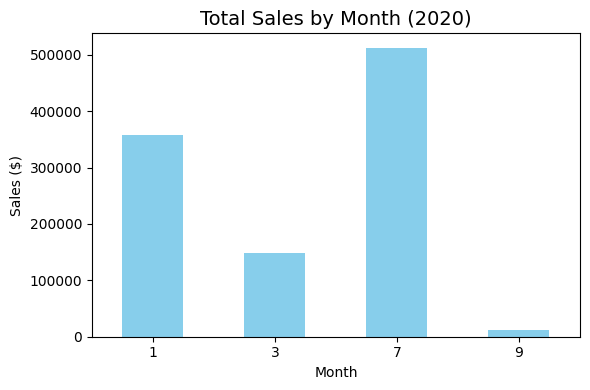

In [21]:
# Total Sales by Month

plt.figure(figsize=(6, 4))
monthly_sales['TOTAL SALES'].plot(kind='bar', color='skyblue')
plt.title('Total Sales by Month (2020)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

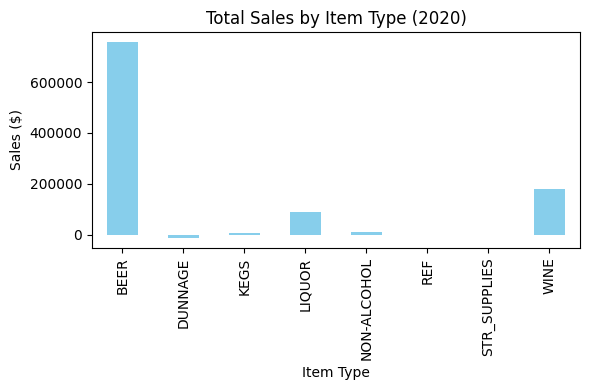

In [22]:
# Sales by Category

plt.figure(figsize=(6, 4))
category_sales['TOTAL SALES'].plot(kind='bar', color='skyblue')
plt.title('Total Sales by Item Type (2020)', fontsize=12)
plt.xlabel('Item Type')
plt.ylabel('Sales ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [23]:
# Retail vs Warehouse Sales

comparison = pd.DataFrame({
    'Retail': df['RETAIL SALES'].sum(),
    'Warehouse': df['WAREHOUSE SALES'].sum()
}, index=['Sales'])

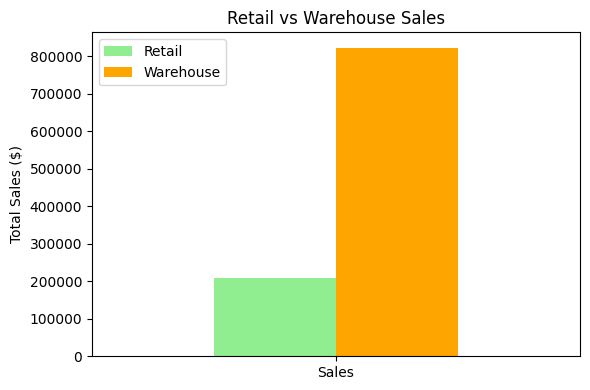

In [24]:
comparison.plot(kind='bar', figsize=(6, 4), color=['lightgreen', 'orange'])
plt.title('Retail vs Warehouse Sales')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

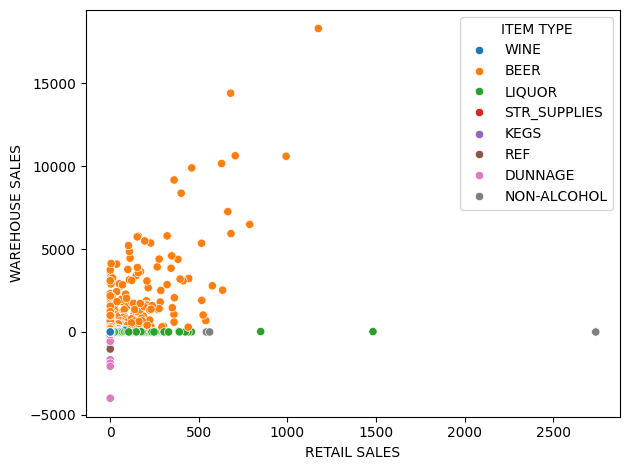

In [25]:
plt.figsize=(8, 6)
sns.scatterplot(x="RETAIL SALES", y="WAREHOUSE SALES", hue= 'ITEM TYPE', data=df)
plt.tight_layout()
plt.show()

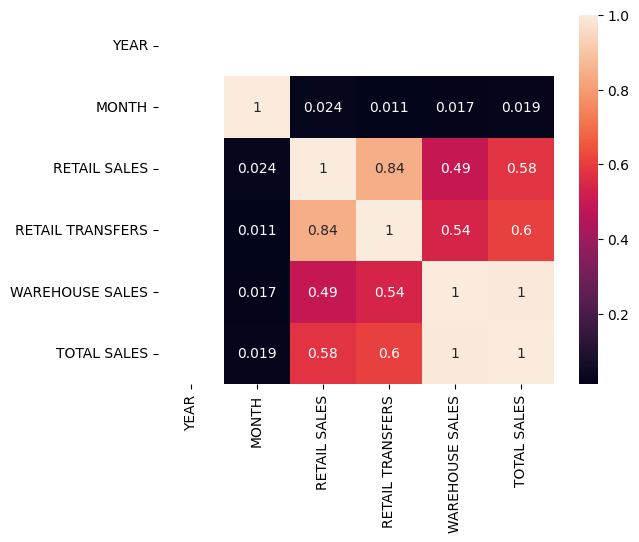

In [26]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

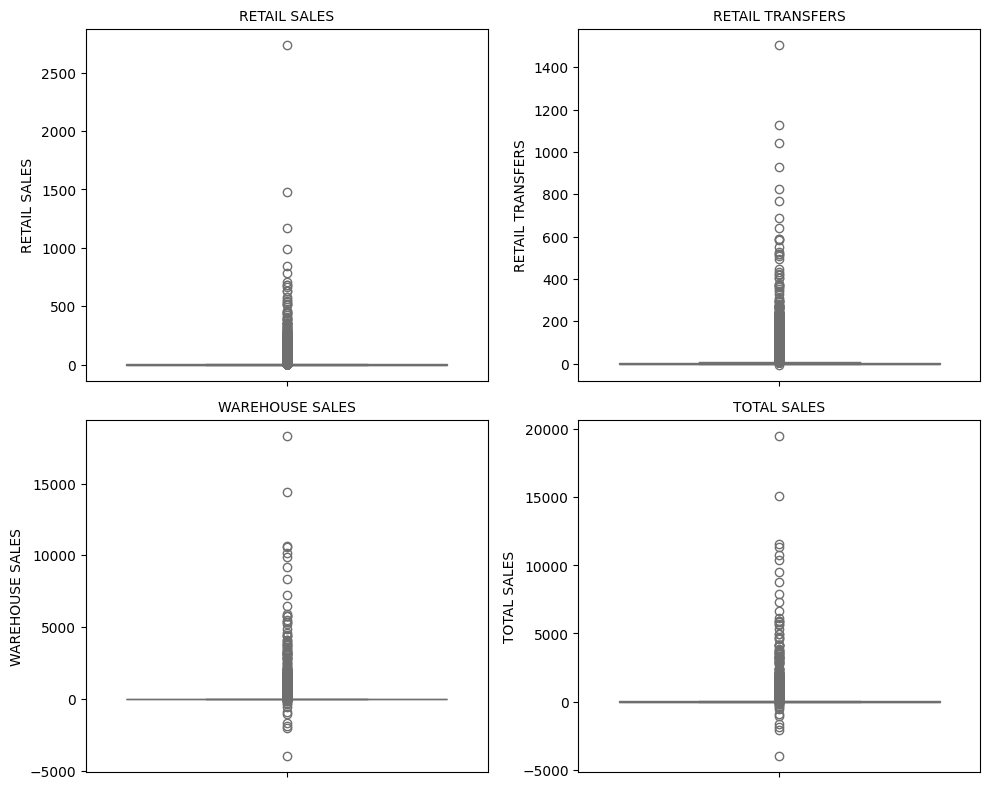

In [27]:
# BOX PLOTS

cols = ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES', 'TOTAL SALES']

plt.figure(figsize=(10, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'{col}', fontsize=10)
    plt.ylabel(col)

plt.tight_layout()
plt.show()

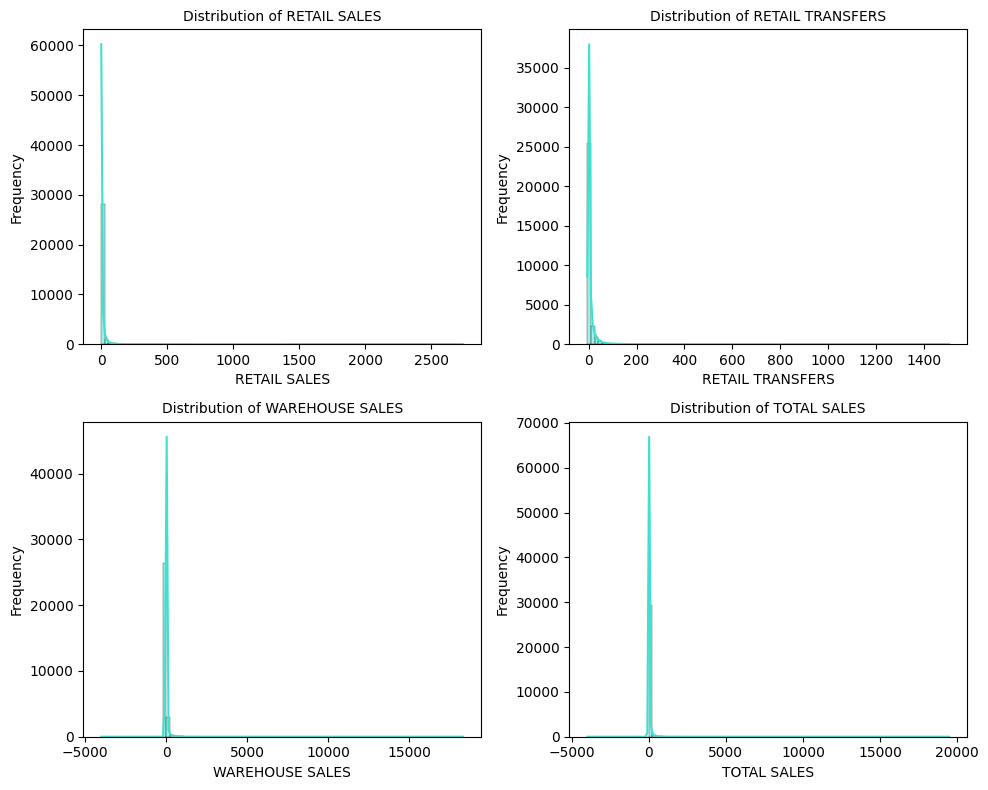

In [28]:
# DISTRIBUTION PLOTS (Histogram + KDE)

plt.figure(figsize=(10, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], bins=100, kde=True, color='turquoise')
    plt.title(f'Distribution of {col}', fontsize=10)
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [29]:
# Count negatives
print("\nNegative Counts:\n")
for col in ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES', 'TOTAL SALES']:
    print(f"{col}: {(df[col] < 0).sum()} negatives")


Negative Counts:

RETAIL SALES: 6 negatives
RETAIL TRANSFERS: 16 negatives
WAREHOUSE SALES: 76 negatives
TOTAL SALES: 78 negatives


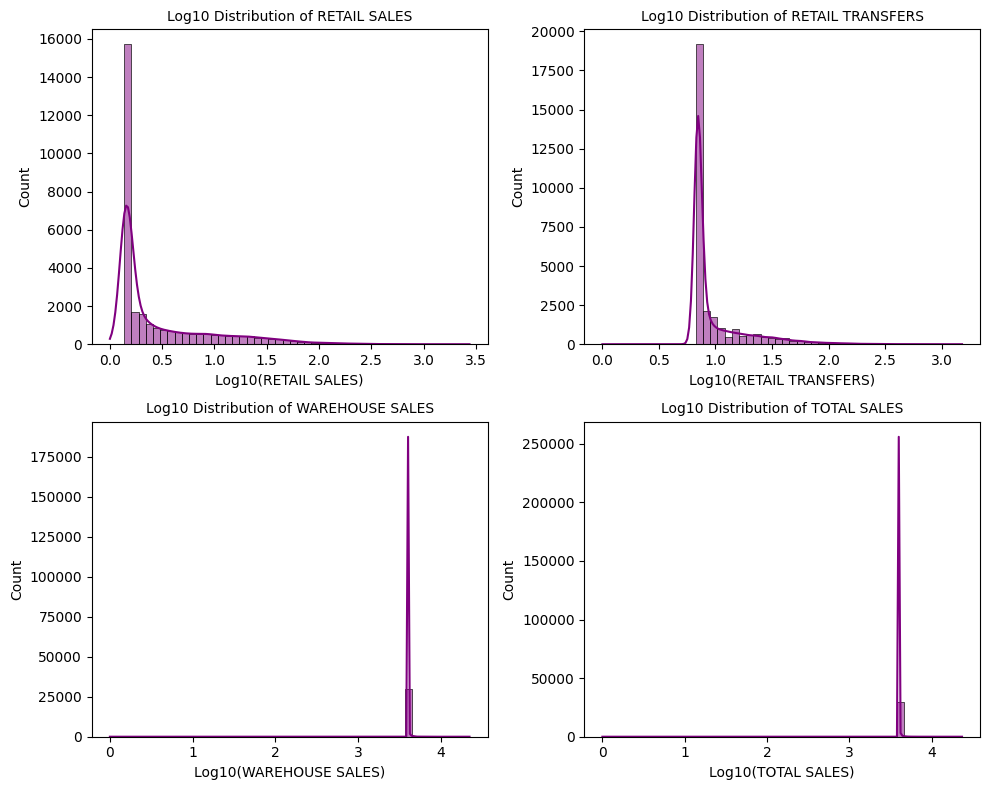

In [30]:
# LOG TRANSFORMED DISTRIBUTION

plt.figure(figsize=(10, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    # Add small constant to avoid log(0) or log(negative)
    data = df[col] + abs(df[col].min()) + 1 if df[col].min() < 0 else df[col] + 1
    sns.histplot(np.log10(data), bins=50, kde=True, color='purple')
    plt.title(f'Log10 Distribution of {col}', fontsize=10)
    plt.xlabel(f'Log10({col})')

plt.tight_layout()
plt.show()

In [31]:
print("\n" + "-"*60 + "\nOUTLIER SUMMARY\n" + "-"*60)

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # Give all values in this column that are either too small or too large based on IQR limits
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    
    print(f"\n{col}:")
    print(f"   Lower Bound : {lower:,.2f}")
    print(f"   Upper Bound : {upper:,.2f}")
    print(f"   Outliers    : {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    print(f"   Min Outlier : {outliers.min():,.2f}")
    print(f"   Max Outlier : {outliers.max():,.2f}")


------------------------------------------------------------
OUTLIER SUMMARY
------------------------------------------------------------

RETAIL SALES:
   Lower Bound : -4.38
   Upper Bound : 7.30
   Outliers    : 5019 (16.73%)
   Min Outlier : 7.31
   Max Outlier : 2,739.00

RETAIL TRANSFERS:
   Lower Bound : -4.50
   Upper Bound : 7.50
   Outliers    : 5070 (16.90%)
   Min Outlier : -6.00
   Max Outlier : 1,507.00

WAREHOUSE SALES:
   Lower Bound : -9.00
   Upper Bound : 15.00
   Outliers    : 3835 (12.78%)
   Min Outlier : -3,999.00
   Max Outlier : 18,317.00

TOTAL SALES:
   Lower Bound : -14.00
   Upper Bound : 26.00
   Outliers    : 4362 (14.54%)
   Min Outlier : -3,999.00
   Max Outlier : 19,491.00


In [32]:
df_treated = df.copy()

for col in cols:
    upper_limit = df[col].quantile(0.99)      # Cap at 99th percentile
    # limits extreme values
    df_treated[col + '_capped'] = df[col].clip(upper=upper_limit)

print("\nOutlier Treatment Completed (Capped at 99th percentile)")


Outlier Treatment Completed (Capped at 99th percentile)


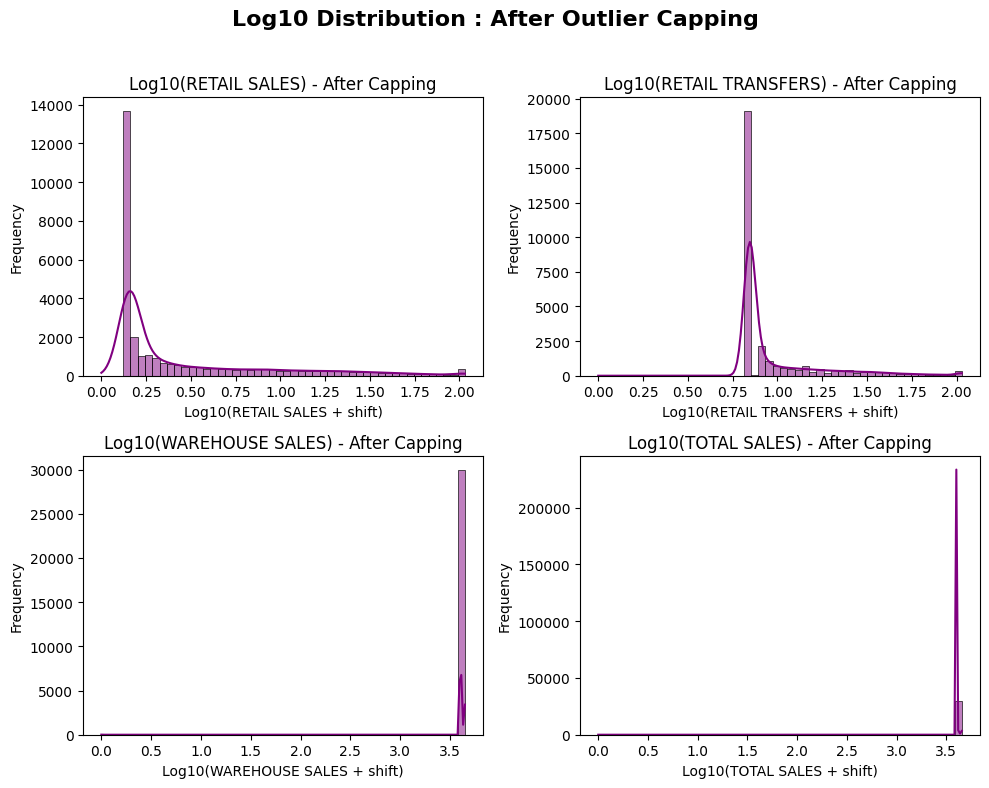

In [33]:
plt.figure(figsize=(10, 8))

plt.suptitle('Log10 Distribution : After Outlier Capping', fontsize=16, fontweight='bold')

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    
    data = df_treated[col + '_capped']
    
    # Properly shifts the data to make all values positive
    min_value = data.min()
    if min_value < 0:
        shifted_data = data - min_value + 1
    else:
        shifted_data = data + 1
    
    # Now take log
    log_data = np.log10(shifted_data)
    
    sns.histplot(log_data, bins=50, kde=True, color='purple')
    plt.title(f'Log10({col}) - After Capping')
    plt.xlabel(f'Log10({col} + shift)')
    plt.ylabel('Frequency')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [34]:
print("\n" + "-"*60 + "\nOUTLIER SUMMARY\n" + "-"*60)

for col in cols:
    # Before Treatment
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_before = df[(df[col] < lower) | (df[col] > upper)][col]
    
    # After Treatment
    outliers_after = df_treated[(df_treated[col + '_capped'] < lower) | 
                                (df_treated[col + '_capped'] > upper)][col + '_capped']
    
    print(f"\n{col}:")
    print(f"   Lower Bound     : {lower:,.2f}")
    print(f"   Upper Bound     : {upper:,.2f}")
    print(f"   Outliers Before : {len(outliers_before)} ({len(outliers_before)/len(df)*100:.2f}%)")
    print(f"   Outliers After  : {len(outliers_after)} ({len(outliers_after)/len(df)*100:.2f}%)")
    print(f"   Max Before      : {df[col].max():,.2f}")
    print(f"   Max After       : {df_treated[col + '_capped'].max():,.2f}")


------------------------------------------------------------
OUTLIER SUMMARY
------------------------------------------------------------

RETAIL SALES:
   Lower Bound     : -4.38
   Upper Bound     : 7.30
   Outliers Before : 5019 (16.73%)
   Outliers After  : 5019 (16.73%)
   Max Before      : 2,739.00
   Max After       : 105.88

RETAIL TRANSFERS:
   Lower Bound     : -4.50
   Upper Bound     : 7.50
   Outliers Before : 5070 (16.90%)
   Outliers After  : 5070 (16.90%)
   Max Before      : 1,507.00
   Max After       : 100.00

WAREHOUSE SALES:
   Lower Bound     : -9.00
   Upper Bound     : 15.00
   Outliers Before : 3835 (12.78%)
   Outliers After  : 3835 (12.78%)
   Max Before      : 18,317.00
   Max After       : 462.61

TOTAL SALES:
   Lower Bound     : -14.00
   Upper Bound     : 26.00
   Outliers Before : 4362 (14.54%)
   Outliers After  : 4362 (14.54%)
   Max Before      : 19,491.00
   Max After       : 531.01


In [35]:
import sys
!{sys.executable} -m pip install sqlalchemy psycopg2-binary --upgrade

In [36]:
# connect data with database
!pip install psycopg2-binary sqlalchemy

In [37]:
from sqlalchemy import create_engine

username = "abc"
password = "your_password"
host = "localhost"
port = "1433"
database = 'retail_and_warehouse'

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

table_name = "sales"
df.to_sql(table_name, engine, if_exists="replace", index= False)

print(f"Data is successfully loaded into the table '{table_name}' in database '{database}'.")

Data is successfully loaded into the table 'sales' in database 'retail_and_warehouse'.
